In [1]:
import pandas as pd
import matplotlib.pyplot as plt

arquivo = "Tabela_13_Meio_de_transporte.xlsx"


In [3]:
# Lendo a aba do Brasil
df = pd.read_excel(arquivo, sheet_name="Exemplo gráfico Brasil", header=1)

df = df.rename(columns={
    "Meio de transporte/cor ou raça": "Meio de Transporte",
    "Preta ou parda": "Preta ou Parda"
})

df


,Meio de Transporte,Branca,Preta ou Parda,Indígena
0,A pé,19.4,24.8,37.5
1,Bicicleta,3.2,5.2,5.9
2,Motocicleta ou Mototaxi,9.9,14.2,15.4
3,"Automóvel, taxi ou assemelhados",41.8,20.6,15.2
4,Transporte coletivo,25.2,34.6,22.4
5,Outros,0.5,0.6,3.6


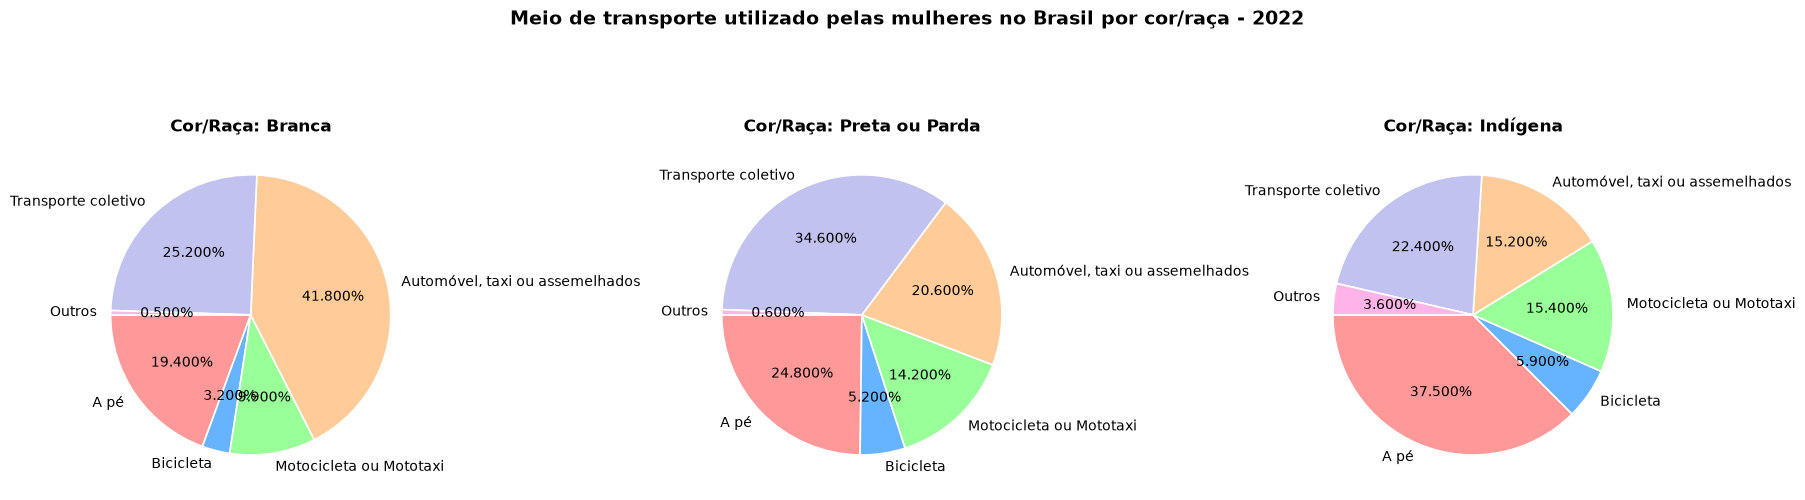

In [4]:
# Pie charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cores = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']
grupos = ['Branca', 'Preta ou Parda', 'Indígena']

for i, col in enumerate(grupos):
    axes[i].pie(
        df[col],
        labels=df['Meio de Transporte'],
        autopct='%1.3f%%',
        startangle=180,
        colors=cores,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    )
    axes[i].set_title(f'Cor/Raça: {col}', fontsize=12, fontweight='bold')

plt.suptitle(
    'Meio de transporte utilizado pelas mulheres no Brasil por cor/raça - 2022',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.savefig('grafico_transporte.png', dpi=300, bbox_inches='tight')
plt.show()


In [6]:
# Calculando automaticamente as diferenças entre cada grupo
grupos = ['Branca', 'Preta ou Parda', 'Indígena']

for _, linha in df.iterrows():
    meio = linha['Meio de Transporte']
    print(f"\n{meio}")
    for i in range(len(grupos)):
        for j in range(i + 1, len(grupos)):
            g1, g2 = grupos[i], grupos[j]
            diferenca = abs(linha[g1] - linha[g2])
            print(f"{g1} x {g2}: {diferenca:.1f} pontos percentuais")



A pé
Branca x Preta ou Parda: 5.4 pontos percentuais
Branca x Indígena: 18.1 pontos percentuais
Preta ou Parda x Indígena: 12.7 pontos percentuais

Bicicleta
Branca x Preta ou Parda: 2.0 pontos percentuais
Branca x Indígena: 2.7 pontos percentuais
Preta ou Parda x Indígena: 0.7 pontos percentuais

Motocicleta ou Mototaxi
Branca x Preta ou Parda: 4.3 pontos percentuais
Branca x Indígena: 5.5 pontos percentuais
Preta ou Parda x Indígena: 1.2 pontos percentuais

Automóvel, taxi ou assemelhados
Branca x Preta ou Parda: 21.2 pontos percentuais
Branca x Indígena: 26.6 pontos percentuais
Preta ou Parda x Indígena: 5.4 pontos percentuais

Transporte coletivo
Branca x Preta ou Parda: 9.4 pontos percentuais
Branca x Indígena: 2.8 pontos percentuais
Preta ou Parda x Indígena: 12.2 pontos percentuais

Outros
Branca x Preta ou Parda: 0.1 pontos percentuais
Branca x Indígena: 3.1 pontos percentuais
Preta ou Parda x Indígena: 3.0 pontos percentuais


In [7]:
# Lendo a aba BR GR UF MU
df2 = pd.read_excel(arquivo, sheet_name="BR GR UF MU", header=None)
df2.head(10)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,Tabela 13 - Distribuição percentual das mulher...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Brasil, Grande Região, Unidade da Federação e ...",Branca,NaN,NaN,NaN,NaN,NaN,Preta ou Parda,NaN,NaN,NaN,NaN,NaN,Indígena,NaN,NaN,NaN,NaN,NaN
2,NaN,A pé,Bicicleta,Motocicleta ou Mototaxi,"Automóvel, taxi ou assemelhados",Transporte coletivo,Outros,A pé,Bicicleta,Motocicleta ou Mototaxi,"Automóvel, taxi ou assemelhados",Transporte coletivo,Outros,A pé,Bicicleta,Motocicleta ou Mototaxi,"Automóvel, taxi ou assemelhados",Transporte coletivo,Outros
3,Brasil,19.4,3.2,9.9,41.8,25.2,0.5,24.8,5.2,14.2,20.6,34.6,0.6,37.5,5.9,15.4,15.2,22.4,3.6
4,Norte,15.2,5.9,24.5,35.1,17.9,1.3,21.3,8.6,27.7,19.5,20.8,2.1,46.8,4.8,19.2,9.5,9.1,10.6
5,Nordeste,24.9,2.6,19.9,31.6,20.5,0.5,31.7,4.1,20.8,16.9,26,0.6,42,4.2,19.4,13.1,20.6,0.7
6,Sudeste,18.5,2.7,7.1,40.4,30.8,0.5,23,4.5,7,19.5,45.5,0.5,26.2,5.6,5.9,22.3,39.4,0.6
7,Sul,20.8,3.5,7.3,48,20,0.5,24,5.5,8.6,29.2,32.2,0.5,31.1,3.1,5.7,22.8,36.4,1
8,Centro-oeste,12.3,4.9,15,49,18.2,0.4,16.1,7.7,18.3,29.4,28,0.4,24.5,16.2,17.5,18.3,22.9,0.7
9,Rondônia,11.7,7.2,36.7,39.3,4.5,0.6,14.8,12.8,39.9,25.5,6.6,0.4,36.3,17.8,29.9,13.4,1.9,0.6


In [8]:
# Transformando os dados para o formato longo
meios = [
    'A pé',
    'Bicicleta',
    'Motocicleta ou Mototaxi',
    'Automóvel, taxi ou assemelhados',
    'Transporte coletivo',
    'Outros'
]

racas = ['Branca', 'Preta ou Parda', 'Indígena']

dados = []

for i in range(3, len(df2)):
    local = df2.iloc[i, 0]
    if pd.isna(local):
        continue

    for r, raca in enumerate(racas):
        inicio = 1 + (r * 6)

        for m, meio in enumerate(meios):
            valor = df2.iloc[i, inicio + m]
            dados.append([local, raca, meio, valor])

df_long = pd.DataFrame(
    dados,
    columns=['Local', 'Raça', 'Meio de Transporte', 'Percentual']
)

df_long['Percentual'] = pd.to_numeric(df_long['Percentual'], errors='coerce')
df_long.head()


,Local,Raça,Meio de Transporte,Percentual
0,Brasil,Branca,A pé,19.4
1,Brasil,Branca,Bicicleta,3.2
2,Brasil,Branca,Motocicleta ou Mototaxi,9.9
3,Brasil,Branca,"Automóvel, taxi ou assemelhados",41.8
4,Brasil,Branca,Transporte coletivo,25.2


In [9]:
# Lista dos estados
estados = [
    'Rondônia','Acre','Amazonas','Roraima','Pará','Amapá','Tocantins',
    'Maranhão','Piauí','Ceará','Rio Grande do Norte','Paraíba','Pernambuco',
    'Alagoas','Sergipe','Bahia','Minas Gerais','Espírito Santo','Rio de Janeiro',
    'São Paulo','Paraná','Santa Catarina','Rio Grande do Sul','Mato Grosso do Sul',
    'Mato Grosso','Goiás','Distrito Federal'
]

df_estados = df_long[df_long['Local'].isin(estados)].copy()

print("Estados encontrados:", df_estados['Local'].nunique())
sorted(df_estados['Local'].unique())


Estados encontrados: 27


['Acre',
 'Alagoas',
 'Amapá',
 'Amazonas',
 'Bahia',
 'Ceará',
 'Distrito Federal',
 'Espírito Santo',
 'Goiás',
 'Maranhão',
 'Mato Grosso',
 'Mato Grosso do Sul',
 'Minas Gerais',
 'Paraná',
 'Paraíba',
 'Pará',
 'Pernambuco',
 'Piauí',
 'Rio Grande do Norte',
 'Rio Grande do Sul',
 'Rio de Janeiro',
 'Rondônia',
 'Roraima',
 'Santa Catarina',
 'Sergipe',
 'São Paulo',
 'Tocantins']

In [10]:
# GROUPBY: média dos percentuais disponíveis por estado e meio de transporte
estados_geral = (
    df_estados
    .groupby(['Local', 'Meio de Transporte'], as_index=False)['Percentual']
    .mean()
)

coletivo = estados_geral[
    estados_geral['Meio de Transporte'] == 'Transporte coletivo'
].dropna()

estado_mais = coletivo.loc[coletivo['Percentual'].idxmax()]
estado_menos = coletivo.loc[coletivo['Percentual'].idxmin()]

print("MAIS transporte coletivo:")
print(estado_mais)
print("\nMENOS transporte coletivo:")
print(estado_menos)


MAIS transporte coletivo:
Local                      Rio de Janeiro
Meio de Transporte    Transporte coletivo
Percentual                      52.233333
Name: 125, dtype: object

MENOS transporte coletivo:
Local                            Rondônia
Meio de Transporte    Transporte coletivo
Percentual                       4.333333
Name: 131, dtype: object


In [11]:
# Separando os municípios
regioes = ['Brasil', 'Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-oeste', 'Centro-Oeste']
nao_municipios = estados + regioes

df_municipios = df_long[
    ~df_long['Local'].isin(nao_municipios)
].copy()

municipios_geral = (
    df_municipios
    .groupby(['Local', 'Meio de Transporte'], as_index=False)['Percentual']
    .mean()
)

bicicleta = municipios_geral[
    municipios_geral['Meio de Transporte'] == 'Bicicleta'
].dropna()

carro = municipios_geral[
    municipios_geral['Meio de Transporte'] == 'Automóvel, taxi ou assemelhados'
].dropna()

cidade_bicicleta = bicicleta.loc[bicicleta['Percentual'].idxmax()]
cidade_carro = carro.loc[carro['Percentual'].idxmax()]

print("Cidade com maior percentual de bicicleta:")
print(cidade_bicicleta)

print("\nCidade com maior percentual de automóvel:")
print(cidade_carro)


Cidade com maior percentual de bicicleta:
Local                 Tuiuti (SP)
Meio de Transporte      Bicicleta
Percentual                  100.0
Name: 31658, dtype: object

Cidade com maior percentual de automóvel:
Local                         Bom Jesus do Oeste (SC)
Meio de Transporte    Automóvel, taxi ou assemelhados
Percentual                                      86.05
Name: 3919, dtype: object
